In [1]:
%matplotlib inline

In [ ]:
# Imports
import os
import pathlib
SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote") # Site name given in the installation of Salvus flow
PROJECT_DIR_VECTOR = "simulation_wavefield_output_larger"  
PROJECT_DIR_TENSOR = "simulation_wavefield_output_moment_tensor_bigger"  
PROJECT_DIR_MOVING_SUBSUB = "simulation_wavefield_moving_source_momentt_subrayleigh" 
PROJECT_DIR_MOVING_SUB = "simulation_wavefield_moving_source_momentt_slight_subrayleigh" 
PROJECT_DIR_MOVING_MOMENTT = "simulation_wavefield_moving_source_momentt"

# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR_VECTOR not in contents:
        f.write(f"\n{PROJECT_DIR_VECTOR }/\n")
    if PROJECT_DIR_TENSOR not in contents:
        f.write(f"\n{PROJECT_DIR_TENSOR }/\n")
    if PROJECT_DIR_MOVING_SUBSUB not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_SUBSUB }/\n")
    if PROJECT_DIR_MOVING_SUB not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_SUB }/\n")
    if PROJECT_DIR_MOVING_MOMENTT not in contents:
        f.write(f"\n{PROJECT_DIR_MOVING_MOMENTT }/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.70 seconds]


In [ ]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=300, y0=0, y1=3)
p_v = sn.Project.from_domain(path=PROJECT_DIR_VECTOR, domain=domain_2d, load_if_exists=True)
p_t = sn.Project.from_domain(path=PROJECT_DIR_TENSOR, domain=domain_2d, load_if_exists=True)
p_moving_subsub = sn.Project.from_domain(path=PROJECT_DIR_MOVING_SUBSUB, domain=domain_2d, load_if_exists=True)
p_moving_sub = sn.Project.from_domain(path=PROJECT_DIR_MOVING_SUB, domain=domain_2d, load_if_exists=True)
p_moving_momentt = sn.Project.from_domain(path=PROJECT_DIR_MOVING_MOMENTT, domain=domain_2d, load_if_exists=True)

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-02 15:55:39,886] INFO: Loading project from simulation_wavefield_output_larger.


Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-02 15:55:39,904] INFO: Loading project from simulation_wavefield_output_moment_tensor_bigger.


In [4]:
# Extracting wavefield data
out_2d_layered_v = p_v.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

vel_wo_layered_v = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered_v,
        "volume_data_output.h5",
    ),
    "velocity",
    "volume",
)

# Converting to an x array
vel_2d_layered_v = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_v,
    points=[np.linspace(0, 30, 101), np.linspace(0, 3, 101)],
)

out_2d_layered_t = p_t.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

vel_wo_layered_t = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered_t,
        "volume_data_output.h5",
    ),
    "velocity",
    "volume",
)

# Converting to an x array
vel_2d_layered_t = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_t,
    points=[np.linspace(0, 30, 101), np.linspace(0, 3, 101)],
)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/10201 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/6868 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 7 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

Finding enclosing elements (pass 8 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

Finding enclosing elements (pass 9 of auto):   0%|          | 0/3434 [00:00<?, ?it/s]

[2026-04-02 15:57:58,000] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 3434 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/14 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_3527535/4167251638.py:65: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


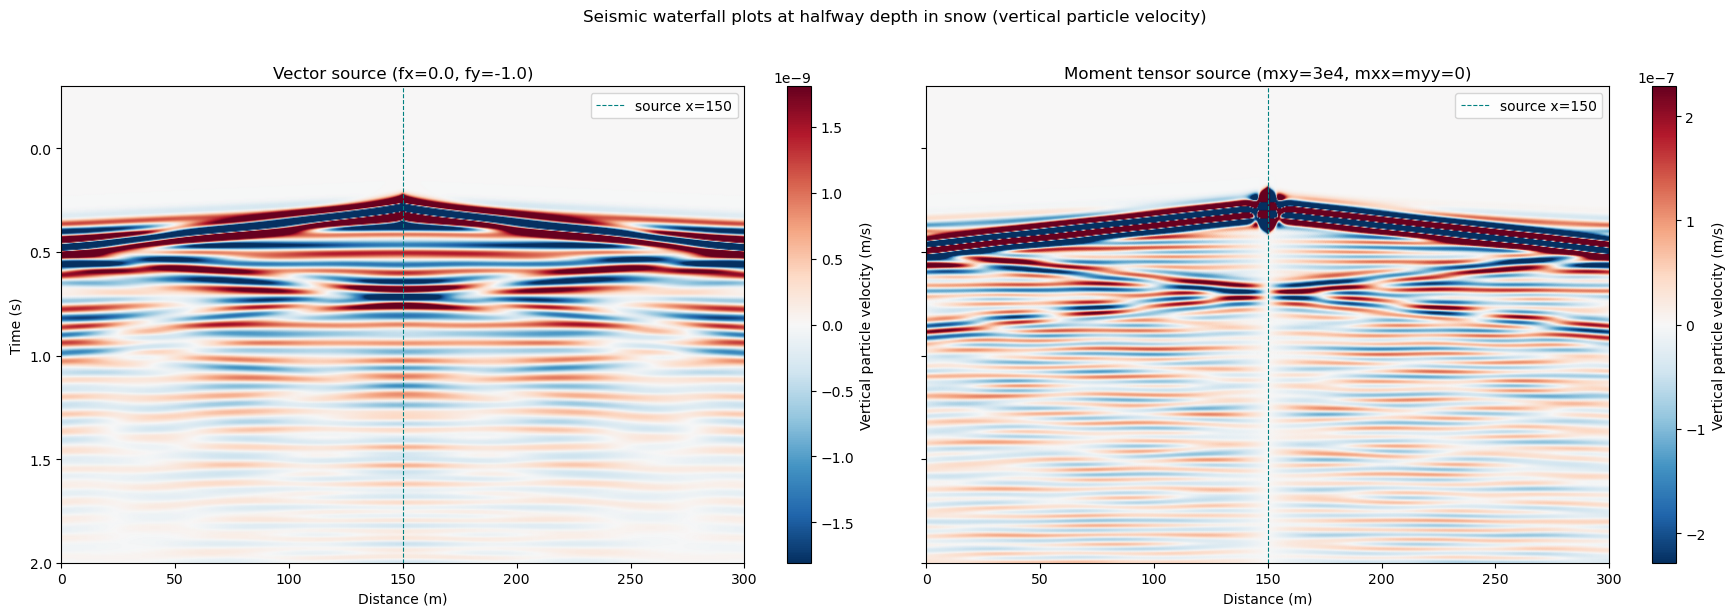

In [7]:
# Plotting the waterfall plots next to each other

# Define receiver line at snow-earth interface
y_surface = 3 * 2 / 3  # middle of snow layer
#y_surface = 3 * 1 / 3 # snow-air interface
x_line = np.linspace(0.0, 300.0, 1001)
y_line = np.full_like(x_line, y_surface)

# Extract wavefield along receiver line for vector source
vel_sg_v = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_v,
    points=np.column_stack((x_line, y_line)),
)
sg_vy_v = vel_sg_v.isel(c=1)
t_vals_v = sg_vy_v.t.values
data_v = sg_vy_v.values  # shape: (n_t, n_points)
vmax_v = np.percentile(np.abs(data_v), 95)

# Extract wavefield along receiver line for moment tensor source
vel_sg_t = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered_t,
    points=np.column_stack((x_line, y_line)),
)
sg_vy_t = vel_sg_t.isel(c=1)
t_vals_t = sg_vy_t.t.values
data_t = sg_vy_t.values  # shape: (n_t, n_points)
vmax_t = np.percentile(np.abs(data_t), 95)

# Create one figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

im_v = axes[0].pcolormesh(
    x_line, t_vals_v, data_v,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax_v, vmax=vmax_v,
)
axes[0].invert_yaxis()
axes[0].axvline(x=150, color="teal", lw=0.8, linestyle="--", label="source x=150")
axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 300)
axes[0].set_title("Vector source (fx=0.0, fy=-1.0)")
axes[0].legend()
fig.colorbar(im_v, ax=axes[0], label="Vertical particle velocity (m/s)")

im_t = axes[1].pcolormesh(
    x_line, t_vals_t, data_t,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax_t, vmax=vmax_t,
)
axes[1].axvline(x=150, color="teal", lw=0.8, linestyle="--", label="source x=150")
axes[1].set_xlabel("Distance (m)")
axes[1].set_xlim(0, 300)
axes[1].set_title("Moment tensor source (mxy=3e4, mxx=myy=0)")
axes[1].legend()
fig.colorbar(im_t, ax=axes[1], label="Vertical particle velocity (m/s)")

fig.suptitle(
    "Seismic waterfall plots at halfway depth in snow (vertical particle velocity)",
    y=1.02,
    fontsize=12,
)
plt.tight_layout()
plt.show()

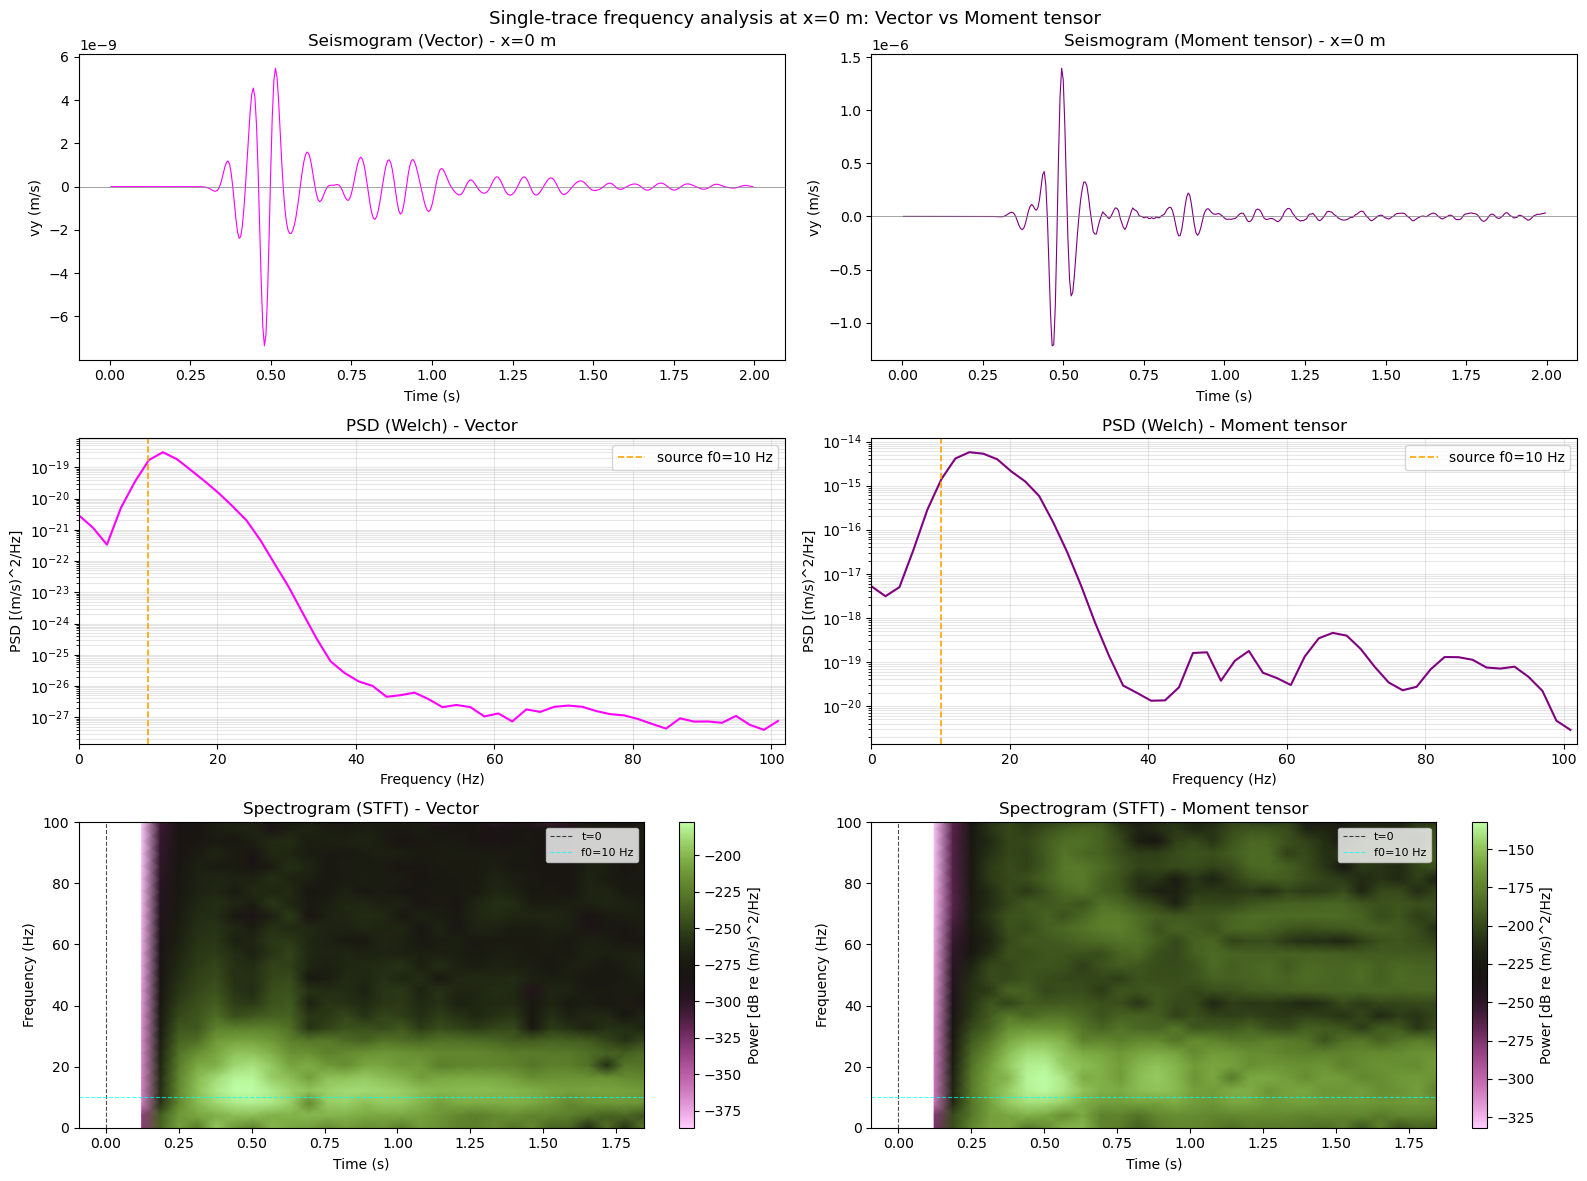

In [10]:
# Frequency-domain comparison for vector and moment tensor sources

# Extracting traces at x=0 m and same time window
trace_v = vel_sg_v.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals_v = trace_v.t.values
y_vals_v = trace_v.values

trace_t = vel_sg_t.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals_t = trace_t.t.values
y_vals_t = trace_t.values

# dt and sampling frequency
dt_v = float(np.diff(t_vals_v).mean())
fs_v = 1.0 / dt_v

dt_t = float(np.diff(t_vals_t).mean())
fs_t = 1.0 / dt_t

fig, axes = plt.subplots(3, 2, figsize=(16, 12))


# Row 1: Raw seismograms ###################

axes[0, 0].plot(t_vals_v, y_vals_v, lw=0.8, color="magenta")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("vy (m/s)")
axes[0, 0].set_title("Seismogram (Vector) - x=0 m")
axes[0, 0].axhline(0, color="gray", lw=0.5)

axes[0, 1].plot(t_vals_t, y_vals_t, lw=0.8, color="purple")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("vy (m/s)")
axes[0, 1].set_title("Seismogram (Moment tensor) - x=0 m")
axes[0, 1].axhline(0, color="gray", lw=0.5)


# Row 2: PSD (Welch) ##########################

nperseg_v = min(1024, len(y_vals_v) // 4)
freqs_psd_v, psd_v = signal.welch(
    y_vals_v,
    fs=fs_v,
    nperseg=nperseg_v,
    noverlap=nperseg_v // 2,
    window="hann",      # reduces spectral leakage
    scaling="density",  # units: (m/s)^2/Hz
)
axes[1, 0].semilogy(freqs_psd_v, psd_v, color="magenta")
axes[1, 0].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1, 0].set_title("PSD (Welch) - Vector")
axes[1, 0].set_xlim(0, fs_v / 2)
axes[1, 0].legend()
axes[1, 0].grid(True, which="both", alpha=0.3)

nperseg_t = min(1024, len(y_vals_t) // 4)
freqs_psd_t, psd_t = signal.welch(
    y_vals_t,
    fs=fs_t,
    nperseg=nperseg_t,
    noverlap=nperseg_t // 2,
    window="hann",
    scaling="density",
)
axes[1, 1].semilogy(freqs_psd_t, psd_t, color="purple")
axes[1, 1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1, 1].set_title("PSD (Welch) - Moment tensor")
axes[1, 1].set_xlim(0, fs_t / 2)
axes[1, 1].legend()
axes[1, 1].grid(True, which="both", alpha=0.3)


# Row 3: Spectrograms (STFT) ######################

nperseg_stft_v = min(512, len(y_vals_v) // 8)
freqs_stft_v, t_stft_v, Sxx_v = signal.spectrogram(
    y_vals_v,
    fs=fs_v,
    nperseg=nperseg_stft_v,
    noverlap=nperseg_stft_v * 3 // 4,  # 75% overlap for smoother time axis
    window="hann",
    scaling="density",
)
Sxx_log_v = 10 * np.log10(Sxx_v + 1e-40)  # dB floor to avoid log(0)
im_v = axes[2, 0].pcolormesh(
    t_stft_v, freqs_stft_v, Sxx_log_v,
    shading="gouraud",
    cmap="vanimo",
)
axes[2, 0].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0")
axes[2, 0].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Frequency (Hz)")
axes[2, 0].set_title("Spectrogram (STFT) - Vector")
axes[2, 0].set_ylim(0, min(100, fs_v / 2))
axes[2, 0].legend(loc="upper right", fontsize=8)
fig.colorbar(im_v, ax=axes[2, 0], label="Power [dB re (m/s)^2/Hz]")

nperseg_stft_t = min(512, len(y_vals_t) // 8)
freqs_stft_t, t_stft_t, Sxx_t = signal.spectrogram(
    y_vals_t,
    fs=fs_t,
    nperseg=nperseg_stft_t,
    noverlap=nperseg_stft_t * 3 // 4,
    window="hann",
    scaling="density",
)
Sxx_log_t = 10 * np.log10(Sxx_t + 1e-40)
im_t = axes[2, 1].pcolormesh(
    t_stft_t, freqs_stft_t, Sxx_log_t,
    shading="gouraud",
    cmap="vanimo",
)
axes[2, 1].axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0")
axes[2, 1].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("Frequency (Hz)")
axes[2, 1].set_title("Spectrogram (STFT) - Moment tensor")
axes[2, 1].set_ylim(0, min(100, fs_t / 2))
axes[2, 1].legend(loc="upper right", fontsize=8)
fig.colorbar(im_t, ax=axes[2, 1], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single-trace frequency analysis at x=0 m: Vector vs Moment tensor", fontsize=13)
plt.tight_layout()
plt.show()